# Strategy S1a — Heuristic Hallucination Injection
## Thesis: Synthetic Data Augmentation for SHROOM-visions

**Core idea**: Fix class imbalance by injecting hallucinations using **pure heuristics — no LLM required**.  
Rules exploit known linguistic patterns: confusable characters for OCR, number-word substitution  
for miscounting, color/attribute swaps for mischaracterization, and template sentences for invention.

**Why heuristic?**
- Zero API cost, zero rate limits, runs fully offline
- Deterministic and reproducible
- OCR corruption is particularly well-suited: confusable chars (O↔0, l↔1, rn↔m) are a closed set

**Injection methods per category**:
| Category | Heuristic |
|---|---|
| OCR | Find quoted/ALL-CAPS text → swap confusable chars, duplicate chars, or insert adjacent key |
| miscounting | Regex-find digit or number-word → shift by ±1 or ±2 |
| mischaracterization | Swap color word with a different color; or swap size/direction antonym |
| invention | Append a fabricated-object sentence from a template list |
| other | Swap temporal, directional, or state words (open↔closed, left↔right) |

**No API key needed.**

In [ ]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
    'unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git', '--quiet'], check=False)
subprocess.run([sys.executable, '-m', 'pip', 'install',
    '--no-deps', 'trl', 'peft', 'accelerate', 'bitsandbytes', '--quiet'], check=False)
subprocess.run([sys.executable, '-m', 'pip', 'install',
    'qwen-vl-utils', 'transformers>=4.45.0',
    'scipy', 'scikit-learn', 'matplotlib', 'seaborn', '--quiet'], check=False)
print('Installation complete.')

Installation complete.


In [ ]:
import json, re, os, io, difflib, random, warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter, defaultdict
from scipy.stats import spearmanr
from tqdm.auto import tqdm
import torch
from datasets import Dataset
from PIL import Image
from qwen_vl_utils import process_vision_info
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU : {torch.cuda.get_device_name(0)}')

CUDA: True
GPU : NVIDIA A100-SXM4-40GB


In [ ]:
# ── Base config ───────────────────────────────────────────────────────────────
MODEL_ID        = 'unsloth/Qwen2-VL-2B-Instruct'
LORA_R          = 16; LORA_ALPHA = 16; LORA_DROPOUT = 0.0
NUM_EPOCHS      = 2;  LR = 2e-4;  BATCH_SIZE = 1;  GRAD_ACCUM = 8
WARMUP_STEPS    = 50; MAX_SEQ_LEN = 2048; MAX_NEW_TOKENS = 512
SAVE_STEPS      = 200; LOG_STEPS = 10
TRAIN_LANGS     = ['en', 'fr', 'it', 'zh']
VAL_FRACTION    = 0.10; RANDOM_SEED = 42; MAX_VAL_SAMPLES = 200

# ── S1a-specific config ────────────────────────────────────────────────────────
STRATEGY           = 'S1a_HeuristicInjection'
TARGET_CATEGORIES  = ['OCR', 'miscounting', 'mischaracterization', 'invention', 'other']
MAX_SYNTH_PER_CAT  = 400   # per language per category — high enough to exhaust all seeds
MAX_SYNTH_PER_LANG = 2000  # hard cap per language — effectively unlimited given seed counts

# ── Paths ─────────────────────────────────────────────────────────────────────
from google.colab import drive; drive.mount('/content/drive')
DRIVE_BASE   = Path('/content/drive/MyDrive/shroom-visions')
DATA_DIR     = DRIVE_BASE / 'distrib'
IMAGE_DIR    = DRIVE_BASE / 'shroom-vis-images'
OUTPUT_DIR   = DRIVE_BASE / f'ft_predictions_{STRATEGY}'
CKPT_DIR     = DRIVE_BASE / f'ft_checkpoints_{STRATEGY}'
BASELINE_CSV = DRIVE_BASE / 'ft_predictions' / 'baseline_results.csv'
SYNTH_CACHE  = DRIVE_BASE / f'synth_cache_{STRATEGY}.json'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

LABEL_ORDER  = ['invention', 'mischaracterization', 'OCR', 'miscounting', 'other']
VALID_LABELS = set(LABEL_ORDER)
LANGUAGES    = ['en', 'fr', 'it', 'zh']
LANG_NAMES   = {'en': 'English', 'fr': 'French', 'it': 'Italian', 'zh': 'Chinese'}

random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)
print(f'Strategy  : {STRATEGY}')
print(f'Target    : {TARGET_CATEGORIES}')
print(f'Cache     : {SYNTH_CACHE}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Strategy  : S1a_HeuristicInjection
Target    : ['OCR', 'miscounting', 'mischaracterization', 'invention', 'other']
Cache     : /content/drive/MyDrive/shroom-visions/synth_cache_S1a_HeuristicInjection.json


In [ ]:
def load_jsonl(path):
    return [json.loads(l) for l in path.read_text(encoding='utf-8').splitlines() if l.strip()]

train_raw, test_raw = {}, {}
for lang in LANGUAGES:
    train_raw[lang] = load_jsonl(DATA_DIR / f'shroom-vision.train.{lang}.labeled.jsonl')
    test_raw[lang]  = load_jsonl(DATA_DIR / f'shroom-vision.test.{lang}.unlabeled.jsonl')
    clean_n = sum(1 for s in train_raw[lang] if not s.get('labels'))
    print(f'{lang.upper()}: {len(train_raw[lang])} train ({clean_n} clean = injection seeds) | {len(test_raw[lang])} test')

EN: 3799 train (962 clean = injection seeds) | 1201 test
FR: 3767 train (964 clean = injection seeds) | 1233 test
IT: 3746 train (986 clean = injection seeds) | 1254 test
ZH: 3790 train (1383 clean = injection seeds) | 1210 test


---
## Strategy S1a — Heuristic Injection Functions

Each category uses a deterministic rule to modify a clean response and produce an exact span annotation.

In [ ]:
# ── OCR confusable character table ───────────────────────────────────────────
OCR_CHAR_MAP = {
    'O': '0', '0': 'O', 'l': '1', '1': 'l', 'I': 'l', 'S': '5', '5': 'S',
    'Z': '2', '2': 'Z', 'B': '8', '8': 'B', 'G': '6', '6': 'G',
    'n': 'u', 'u': 'n', 'a': 'o', 'o': 'a', 'e': 'c', 'c': 'e',
    'h': 'b', 'b': 'h', 'q': 'g', 'g': 'q', 'd': 'a', 'p': 'q',
    'f': 't', 't': 'f', 'v': 'w', 'w': 'v', 'i': 'j', 'j': 'i',
}
KEYBOARD_NEIGHBORS = {
    'a':'s','s':'a','d':'f','f':'d','g':'h','h':'g','j':'k','k':'j',
    'q':'w','w':'q','e':'r','r':'e','t':'y','y':'t','u':'i','i':'u',
    'o':'p','p':'o','z':'x','x':'z','c':'v','v':'c','b':'n','n':'b','m':'n',
}

# OCR indicator phrases per language
OCR_INDICATOR_PHRASES = {
    'en': [r'reads?', r'says?', r'shows?', r'written', r'text'],
    'fr': [r'indique', r'lit', r'dit', r'montre', r'écrit', r'texte', r'affiche'],
    'it': [r'indica', r'legge', r'dice', r'mostra', r'scritto', r'testo', r'visualizza'],
    'zh': [r'显示', r'写着', r'标注', r'文字', r'说明', r'写有'],
}

def find_ocr_target(response, lang='en'):
    """Find text likely transcribed from image: quoted, ALL-CAPS, or after indicator phrases."""
    # Quoted strings — standard ASCII and CJK quotation marks
    for pat in [r'"([^"]{2,30})"', r'「([^」]{2,30})」', r'『([^』]{2,30})』']:
        for m in re.finditer(pat, response):
            return m.start(1), m.end(1), m.group(1)
    # Language-specific indicator phrases
    for phrase in OCR_INDICATOR_PHRASES.get(lang, OCR_INDICATOR_PHRASES['en']):
        m = re.search(rf'\b{phrase}\s+["\']?([A-Za-z0-9一-鿿][A-Za-z0-9一-鿿 ,\-]{{2,25}})["\']?',
                      response, re.IGNORECASE)
        if m: return m.start(1), m.end(1), m.group(1).rstrip(' ,.')
    # ALL-CAPS sequence (≥2 non-trivial chars) — language-neutral
    for m in re.finditer(r'\b([A-Z][A-Z0-9]{1,14})\b', response):
        if m.group(1) not in {'I','A','AN','THE','VLM','OCR','AI','OK','ID','TV'}:
            return m.start(1), m.end(1), m.group(1)
    return None

def corrupt_text_ocr(text):
    """Apply one OCR-style corruption: confusable swap, keyboard-neighbor, or char duplication."""
    chars = list(text)
    swappable = [(i, c) for i, c in enumerate(chars) if c in OCR_CHAR_MAP]
    if swappable:
        idx, orig = random.choice(swappable)
        chars[idx] = OCR_CHAR_MAP[orig]
        return ''.join(chars)
    neighborable = [(i, c.lower()) for i, c in enumerate(chars) if c.lower() in KEYBOARD_NEIGHBORS]
    if neighborable:
        idx, orig = random.choice(neighborable)
        replacement = KEYBOARD_NEIGHBORS[orig]
        chars[idx] = replacement.upper() if chars[idx].isupper() else replacement
        return ''.join(chars)
    if len(chars) >= 2:
        idx = random.randint(0, len(chars)-2)
        chars.insert(idx+1, chars[idx])
        return ''.join(chars)
    return text + text[0]

def inject_ocr(sample, lang='en'):
    response = sample['response']
    candidate = find_ocr_target(response, lang=lang)
    if candidate is None: return None
    orig_start, orig_end, orig_text = candidate
    corrupted = corrupt_text_ocr(orig_text)
    if corrupted == orig_text: return None
    new_response = response[:orig_start] + corrupted + response[orig_end:]
    return new_response, orig_start, orig_start + len(corrupted), corrupted


# ── Miscounting ───────────────────────────────────────────────────────────────
NUMBER_WORDS = {
    'en': {
        'one':1,'two':2,'three':3,'four':4,'five':5,'six':6,'seven':7,
        'eight':8,'nine':9,'ten':10,'eleven':11,'twelve':12,'twenty':20,'thirty':30,
    },
    'fr': {
        'un':1,'deux':2,'trois':3,'quatre':4,'cinq':5,'six':6,'sept':7,
        'huit':8,'neuf':9,'dix':10,'onze':11,'douze':12,'vingt':20,'trente':30,
    },
    'it': {
        'uno':1,'due':2,'tre':3,'quattro':4,'cinque':5,'sei':6,'sette':7,
        'otto':8,'nove':9,'dieci':10,'undici':11,'dodici':12,'venti':20,'trenta':30,
    },
    'zh': {
        '一':1,'两':2,'二':2,'三':3,'四':4,'五':5,'六':6,'七':7,
        '八':8,'九':9,'十':10,'十一':11,'十二':12,'二十':20,'三十':30,
    },
}
INV_NUMBER_WORDS = {
    lang: {v: k for k, v in d.items()} for lang, d in NUMBER_WORDS.items()
}

def inject_miscounting(sample, lang='en'):
    response = sample['response']
    # Digits work for all languages
    m = re.search(r'\b([2-9]|[12][0-9])\b', response)
    if m:
        orig = int(m.group())
        delta = random.choice([-2, -1, 1, 2])
        new_val = max(1, orig + delta)
        if new_val == orig: new_val = orig + 1
        new_text = str(new_val)
        new_response = response[:m.start()] + new_text + response[m.end():]
        return new_response, m.start(), m.start() + len(new_text), new_text
    # Language-specific number words
    nw_dict = NUMBER_WORDS.get(lang, NUMBER_WORDS['en'])
    inv_nw  = INV_NUMBER_WORDS.get(lang, INV_NUMBER_WORDS['en'])
    nw_pattern = '|'.join(sorted(nw_dict, key=len, reverse=True))
    flags = 0 if lang == 'zh' else re.IGNORECASE
    sep   = '' if lang == 'zh' else r'\b'
    m = re.search(sep + r'(' + nw_pattern + r')' + sep, response, flags)
    if m:
        orig_val = nw_dict[m.group().lower() if lang != 'zh' else m.group()]
        delta = random.choice([-2, -1, 1, 2])
        new_val = max(1, orig_val + delta)
        if new_val == orig_val: new_val = orig_val + 1
        new_text = inv_nw.get(new_val, str(new_val))
        if lang != 'zh' and m.group()[0].isupper(): new_text = new_text.capitalize()
        new_response = response[:m.start()] + new_text + response[m.end():]
        return new_response, m.start(), m.start() + len(new_text), new_text
    return None


# ── Mischaracterization ───────────────────────────────────────────────────────
COLORS = {
    'en': ['red','blue','green','yellow','orange','purple','pink',
           'brown','black','white','gray','grey','silver','gold','teal','navy'],
    'fr': ['rouge','bleu','bleue','vert','verte','jaune','orange','violet','violette',
           'rose','brun','brune','noir','noire','blanc','blanche','gris','grise',
           'argenté','doré','beige','bordeaux','turquoise'],
    'it': ['rosso','rossa','blu','verde','giallo','gialla','arancione','viola',
           'rosa','marrone','nero','nera','bianco','bianca','grigio','grigia',
           'argento','dorato','beige','turchese','azzurro'],
    'zh': ['红色','蓝色','绿色','黄色','橙色','紫色','粉色','棕色','黑色','白色',
           '灰色','银色','金色','红','蓝','绿','黄','橙','紫','粉','棕','黑','白','灰'],
}

ATTRIBUTE_ANTONYMS = {
    'en': {
        'large':'small','big':'tiny','small':'large','tiny':'big',
        'tall':'short','short':'tall','wide':'narrow','narrow':'wide',
        'long':'short','old':'new','new':'old','dark':'light','light':'dark',
        'bright':'dull','dull':'bright','open':'closed','closed':'open',
        'full':'empty','empty':'full','clean':'dirty','dirty':'clean',
        'left':'right','right':'left','upper':'lower','lower':'upper',
        'front':'back','back':'front','inside':'outside','outside':'inside',
    },
    'fr': {
        'grand':'petit','grande':'petite','petit':'grand','petite':'grande',
        'haut':'bas','haute':'basse','bas':'haut','basse':'haute',
        'large':'étroit','étroite':'large','long':'court','longue':'courte',
        'vieux':'nouveau','vieille':'nouvelle','nouveau':'vieux','nouvelle':'vieille',
        'sombre':'clair','claire':'sombre','ouvert':'fermé','ouverte':'fermée',
        'fermé':'ouvert','fermée':'ouverte','plein':'vide','vide':'plein',
        'gauche':'droite','droite':'gauche','avant':'arrière','arrière':'avant',
        'intérieur':'extérieur','extérieur':'intérieur','propre':'sale','sale':'propre',
    },
    'it': {
        'grande':'piccolo','grandi':'piccoli','piccolo':'grande','piccola':'grande',
        'alto':'basso','alta':'bassa','basso':'alto','bassa':'alta',
        'largo':'stretto','larga':'stretta','lungo':'corto','lunga':'corta',
        'vecchio':'nuovo','vecchia':'nuova','nuovo':'vecchio','nuova':'vecchia',
        'scuro':'chiaro','scura':'chiara','aperto':'chiuso','aperta':'chiusa',
        'chiuso':'aperto','chiusa':'aperta','pieno':'vuoto','vuoto':'pieno',
        'sinistra':'destra','destra':'sinistra','anteriore':'posteriore',
        'interno':'esterno','esterno':'interno','pulito':'sporco','sporco':'pulito',
    },
    'zh': {
        '大':'小','小':'大','高':'低','低':'高','长':'短','短':'长',
        '宽':'窄','窄':'宽','旧':'新','新':'旧','暗':'亮','亮':'暗',
        '开':'关','关':'开','满':'空','空':'满','左':'右','右':'左',
        '前':'后','后':'前','上':'下','下':'上','内':'外','外':'内',
        '干净':'脏','脏':'干净',
    },
}

def inject_mischaracterization(sample, lang='en'):
    response = sample['response']
    lang_colors = COLORS.get(lang, COLORS['en'])
    lang_attrs  = ATTRIBUTE_ANTONYMS.get(lang, ATTRIBUTE_ANTONYMS['en'])

    # Try color swap
    color_pat = '|'.join(sorted(lang_colors, key=len, reverse=True))
    flags = 0 if lang == 'zh' else re.IGNORECASE
    m = re.search(r'(?<!\w)(' + color_pat + r')(?!\w)' if lang == 'zh'
                  else r'\b(' + color_pat + r')\b', response, flags)
    if m:
        orig = m.group()
        options = [c for c in lang_colors if c.lower() != orig.lower()]
        replacement = random.choice(options)
        if lang != 'zh' and orig[0].isupper(): replacement = replacement.capitalize()
        new_response = response[:m.start()] + replacement + response[m.end():]
        return new_response, m.start(), m.start() + len(replacement), replacement

    # Try attribute antonym
    attr_pat = '|'.join(sorted(lang_attrs, key=len, reverse=True))
    m = re.search(r'(' + attr_pat + r')' if lang == 'zh'
                  else r'\b(' + attr_pat + r')\b', response, flags)
    if m:
        key = m.group() if lang == 'zh' else m.group().lower()
        replacement = lang_attrs.get(key, '')
        if not replacement: return None
        if lang != 'zh' and m.group()[0].isupper(): replacement = replacement.capitalize()
        new_response = response[:m.start()] + replacement + response[m.end():]
        return new_response, m.start(), m.start() + len(replacement), replacement
    return None


# ── Invention ─────────────────────────────────────────────────────────────────
INVENTION_OBJECTS = {
    'en': [
        'a clock on the wall', 'a bicycle leaning against the wall',
        'a small potted plant', 'a laptop computer', 'a coffee mug',
        'a red umbrella', 'a backpack on the floor', 'an open book',
        'a framed painting', 'a wooden chair', 'a desk lamp',
        'a dog sitting nearby', 'a cat on a shelf', 'a glass bottle',
        'a pair of glasses', 'a mobile phone', 'a wristwatch',
    ],
    'fr': [
        'une horloge murale', 'un vélo appuyé contre le mur',
        'une petite plante en pot', 'un ordinateur portable', 'une tasse de café',
        'un parapluie rouge', 'un sac à dos par terre', 'un livre ouvert',
        'un tableau encadré', 'une chaise en bois', 'une lampe de bureau',
        'un chien assis là', 'un chat sur une étagère', 'une bouteille en verre',
        'une paire de lunettes', 'un téléphone portable', 'une montre',
    ],
    'it': [
        'un orologio da parete', 'una bicicletta appoggiata al muro',
        'una piccola pianta in vaso', 'un computer portatile', 'una tazza di caffè',
        'un ombrello rosso', 'uno zaino sul pavimento', 'un libro aperto',
        'un quadro incorniciato', 'una sedia di legno', 'una lampada da tavolo',
        'un cane seduto vicino', 'un gatto su uno scaffale', 'una bottiglia di vetro',
        'un paio di occhiali', 'un telefono cellulare', 'un orologio da polso',
    ],
    'zh': [
        '一面挂钟', '一辆靠墙的自行车', '一盆小植物', '一台笔记本电脑',
        '一个咖啡杯', '一把红色雨伞', '一个背包', '一本打开的书',
        '一幅有框画', '一把木椅', '一盏台灯', '一只坐着的狗',
        '一只架子上的猫', '一个玻璃瓶', '一副眼镜', '一部手机', '一块手表',
    ],
}

INVENTION_TEMPLATES = {
    'en': [
        ' There is also {obj} in the image.',
        ' {obj_cap} can be seen in the background.',
        ' In the corner, {obj} is visible.',
        ' The image also features {obj}.',
        ' Additionally, {obj} appears in the scene.',
    ],
    'fr': [
        " Il y a aussi {obj} dans l'image.",
        ' {obj_cap} est visible en arrière-plan.',
        ' Dans le coin, {obj} est visible.',
        " L'image présente également {obj}.",
        ' De plus, {obj} apparaît dans la scène.',
    ],
    'it': [
        " C'è anche {obj} nell'immagine.",
        ' {obj_cap} è visibile sullo sfondo.',
        " Nell'angolo, {obj} è visibile.",
        " L'immagine presenta anche {obj}.",
        ' Inoltre, {obj} appare nella scena.',
    ],
    'zh': [
        ' 图像中还有{obj}。',
        ' 背景中可以看到{obj}。',
        ' 角落里有{obj}。',
        ' 图像中还出现了{obj}。',
        ' 此外，场景中还有{obj}。',
    ],
}

def inject_invention(sample, lang='en'):
    response = sample['response']
    lang_objs = INVENTION_OBJECTS.get(lang, INVENTION_OBJECTS['en'])
    lang_tmpls = INVENTION_TEMPLATES.get(lang, INVENTION_TEMPLATES['en'])
    obj = random.choice(lang_objs)
    template = random.choice(lang_tmpls)
    appended = template.format(obj=obj, obj_cap=obj.capitalize())
    new_response = response.rstrip() + appended
    span_text = appended.strip()
    pos = new_response.rfind(span_text)
    if pos == -1: return None
    return new_response, pos, pos + len(span_text), span_text


# ── Other ─────────────────────────────────────────────────────────────────────
OTHER_SWAPS = {
    'en': {
        'morning':'afternoon','afternoon':'morning','evening':'night','night':'evening',
        'left':'right','right':'left','top':'bottom','bottom':'top',
        'horizontal':'vertical','vertical':'horizontal',
        'indoor':'outdoor','outdoor':'indoor','interior':'exterior','exterior':'interior',
        'modern':'vintage','vintage':'modern','wooden':'metal','metal':'wooden',
        'standing':'sitting','sitting':'standing','walking':'running','running':'walking',
    },
    'fr': {
        'matin':'après-midi','après-midi':'matin','soir':'nuit','nuit':'soir',
        'gauche':'droite','droite':'gauche','haut':'bas','bas':'haut',
        'horizontal':'vertical','vertical':'horizontal',
        'intérieur':'extérieur','extérieur':'intérieur',
        'moderne':'vintage','vintage':'moderne','en bois':'en métal','en métal':'en bois',
        'debout':'assis','assis':'debout','marche':'court','court':'marche',
    },
    'it': {
        'mattina':'pomeriggio','pomeriggio':'mattina','sera':'notte','notte':'sera',
        'sinistra':'destra','destra':'sinistra','sopra':'sotto','sotto':'sopra',
        'orizzontale':'verticale','verticale':'orizzontale',
        'interno':'esterno','esterno':'interno',
        'moderno':'vintage','vintage':'moderno','in legno':'in metallo','in metallo':'in legno',
        'in piedi':'seduto','seduto':'in piedi','cammina':'corre','corre':'cammina',
    },
    'zh': {
        '早上':'下午','下午':'早上','傍晚':'夜间','夜间':'傍晚',
        '左':'右','右':'左','上方':'下方','下方':'上方',
        '水平':'垂直','垂直':'水平','室内':'室外','室外':'室内',
        '现代':'复古','复古':'现代','木制':'金属','金属':'木制',
        '站着':'坐着','坐着':'站着','走路':'跑步','跑步':'走路',
    },
}

def inject_other(sample, lang='en'):
    response = sample['response']
    swaps = OTHER_SWAPS.get(lang, OTHER_SWAPS['en'])
    other_pat = '|'.join(re.escape(k) for k in sorted(swaps, key=len, reverse=True))
    flags = 0 if lang == 'zh' else re.IGNORECASE
    matches = list(re.finditer(other_pat, response, flags))
    if not matches: return None
    m = random.choice(matches)
    key = m.group() if lang == 'zh' else m.group().lower()
    replacement = swaps.get(key, '')
    if not replacement: return None
    if lang != 'zh' and m.group()[0].isupper(): replacement = replacement.capitalize()
    new_response = response[:m.start()] + replacement + response[m.end():]
    return new_response, m.start(), m.start() + len(replacement), replacement


# ── Dispatcher ────────────────────────────────────────────────────────────────
INJECT_FNS = {
    'OCR':               inject_ocr,
    'miscounting':       inject_miscounting,
    'mischaracterization': inject_mischaracterization,
    'invention':         inject_invention,
    'other':             inject_other,
}

def create_heuristic_sample(sample, target_label, prefix, lang='en'):
    fn = INJECT_FNS.get(target_label)
    if fn is None: return None
    result = fn(sample, lang=lang)
    if result is None: return None
    new_response, span_start, span_end, span_text = result
    if not span_text.strip(): return None
    if new_response[span_start:span_end] != span_text: return None
    return {
        'id': f'{prefix}_{target_label}_{sample["id"]}',
        'language': sample.get('language', ''),
        'prompt': sample['prompt'],
        'image_name': sample['image_name'],
        'response': new_response,
        'labels': [{'start': span_start, 'end': span_end, 'prob': 1.0, 'label': target_label}],
    }

print('Heuristic injection functions ready (multilingual, no LLM needed).')

Heuristic injection functions ready (multilingual, no LLM needed).


In [ ]:
REGEN_ALL = True   # clear all cache to regenerate with raised caps + multilingual heuristics

if SYNTH_CACHE.exists():
    synth_cache = json.loads(SYNTH_CACHE.read_text(encoding='utf-8'))
    print(f'Loaded cache: {sum(len(v) for v in synth_cache.values())} synthetic samples')
else:
    synth_cache = {lang: [] for lang in LANGUAGES}

if REGEN_ALL:
    for lang in LANGUAGES:
        dropped = len(synth_cache.get(lang, []))
        synth_cache[lang] = []
        if dropped:
            print(f'  Cleared {dropped} stale {lang.upper()} entries')

def save_cache():
    SYNTH_CACHE.parent.mkdir(parents=True, exist_ok=True)
    SYNTH_CACHE.write_text(json.dumps(synth_cache, ensure_ascii=False, indent=2), encoding='utf-8')

PREFIX = 'synth_s1a'

for lang in TRAIN_LANGS:
    clean_samples = [s for s in train_raw[lang] if not s.get('labels')]
    random.shuffle(clean_samples)
    existing_ids = {s['id'] for s in synth_cache.get(lang, [])}
    cat_counts   = Counter(s['labels'][0]['label'] for s in synth_cache.get(lang, []) if s.get('labels'))
    print(f'\n[{lang.upper()}] {len(clean_samples)} clean seeds | existing: {len(existing_ids)}')

    for target_cat in TARGET_CATEGORIES:
        already = cat_counts.get(target_cat, 0)
        need    = MAX_SYNTH_PER_CAT - already
        if need <= 0:
            print(f'  {target_cat}: already {already}/{MAX_SYNTH_PER_CAT}, skipping')
            continue
        seeds = [s for s in clean_samples
                 if f'{PREFIX}_{target_cat}_{s["id"]}' not in existing_ids]
        ok = fail = 0
        for s in tqdm(seeds, desc=f'{lang}/{target_cat}'):
            if ok >= need or len(synth_cache.get(lang, [])) >= MAX_SYNTH_PER_LANG: break
            result = create_heuristic_sample(s, target_cat, PREFIX, lang=lang)
            if result:
                synth_cache.setdefault(lang, []).append(result)
                cat_counts[target_cat] += 1
                ok += 1
            else:
                fail += 1
        save_cache()
        total = ok + fail
        print(f'  {target_cat}: +{ok}/{len(seeds)} seeds  (fail={fail}, yield={ok/max(total,1)*100:.0f}%)')

synthetic_samples = {lang: synth_cache.get(lang, []) for lang in LANGUAGES}
print('\nFinal synthetic counts:')
for lang in LANGUAGES:
    cnt = Counter(s['labels'][0]['label'] for s in synthetic_samples[lang] if s.get('labels'))
    print(f'  {lang.upper()}: {len(synthetic_samples[lang])} total  {dict(cnt)}')

Loaded cache: 2000 synthetic samples
  Cleared 500 stale EN entries
  Cleared 500 stale FR entries
  Cleared 500 stale IT entries
  Cleared 500 stale ZH entries

[EN] 962 clean seeds | existing: 0


en/OCR:   0%|          | 0/962 [00:00<?, ?it/s]

  OCR: +364/962 seeds  (fail=598, yield=38%)


en/miscounting:   0%|          | 0/962 [00:00<?, ?it/s]

  miscounting: +274/962 seeds  (fail=688, yield=28%)


...

  mischaracterization: +400/1383 seeds  (fail=132, yield=75%)


zh/invention:   0%|          | 0/1383 [00:00<?, ?it/s]

  invention: +400/1383 seeds  (fail=0, yield=100%)


zh/other:   0%|          | 0/1383 [00:00<?, ?it/s]

  other: +272/1383 seeds  (fail=1111, yield=20%)

Final synthetic counts:
  EN: 1798 total  {'OCR': 364, 'miscounting': 274, 'mischaracterization': 400, 'invention': 400, 'other': 360}
  FR: 1586 total  {'OCR': 167, 'miscounting': 400, 'mischaracterization': 400, 'invention': 400, 'other': 219}
  IT: 1264 total  {'OCR': 195, 'miscounting': 139, 'mischaracterization': 400, 'invention': 400, 'other': 130}
  ZH: 1572 total  {'OCR': 100, 'miscounting': 400, 'mischaracterization': 400, 'invention': 400, 'other': 272}


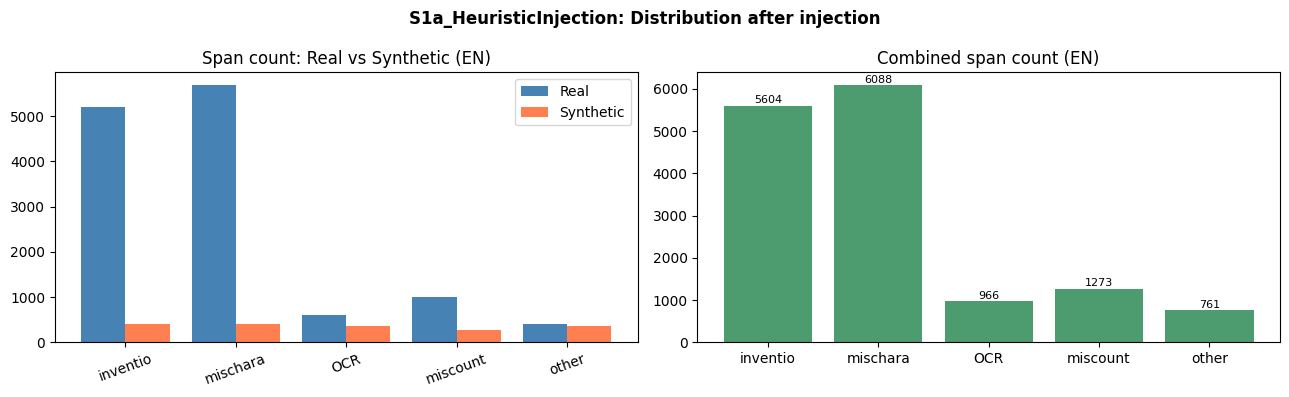

Total synthetic per language:
  EN: 1798 total  {'OCR': 364, 'miscounting': 274, 'mischaracterization': 400, 'invention': 400, 'other': 360}
  FR: 1586 total  {'OCR': 167, 'miscounting': 400, 'mischaracterization': 400, 'invention': 400, 'other': 219}
  IT: 1264 total  {'OCR': 195, 'miscounting': 139, 'mischaracterization': 400, 'invention': 400, 'other': 130}
  ZH: 1572 total  {'OCR': 100, 'miscounting': 400, 'mischaracterization': 400, 'invention': 400, 'other': 272}


In [ ]:
real_cnt   = Counter(lb['label'] for s in train_raw['en'] for lb in s.get('labels', []))
synth_cnt  = Counter(lb['label'] for s in synthetic_samples['en'] for lb in s.get('labels', []))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
cats_short = [c[:8] for c in LABEL_ORDER]
x = np.arange(len(LABEL_ORDER))

ax = axes[0]
ax.bar(x-0.2, [real_cnt.get(c,0) for c in LABEL_ORDER],  0.4, label='Real',      color='steelblue')
ax.bar(x+0.2, [synth_cnt.get(c,0) for c in LABEL_ORDER], 0.4, label='Synthetic', color='coral')
ax.set_xticks(x); ax.set_xticklabels(cats_short, rotation=20)
ax.set_title('Span count: Real vs Synthetic (EN)'); ax.legend()

ax2 = axes[1]
combined = [real_cnt.get(c,0)+synth_cnt.get(c,0) for c in LABEL_ORDER]
ax2.bar(cats_short, combined, color='seagreen', alpha=0.85)
ax2.set_title('Combined span count (EN)')
for xi, v in enumerate(combined):
    ax2.text(xi, v+5, str(v), ha='center', va='bottom', fontsize=8)

plt.suptitle(f'{STRATEGY}: Distribution after injection', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'synth_distribution.png', dpi=150)
plt.show()

print('Total synthetic per language:')
for lang in LANGUAGES:
    cnt = Counter(s['labels'][0]['label'] for s in synthetic_samples[lang] if s.get('labels'))
    print(f'  {lang.upper()}: {len(synthetic_samples[lang])} total  {dict(cnt)}')

In [ ]:
INSTRUCTION = """Identify all hallucinated text spans in the vision model's response.
A hallucination is text that is factually incorrect compared to what is actually visible in the image.

Categories:
- invention: entities or facts completely absent from the image
- mischaracterization: visible content described incorrectly
- OCR: text visible in the image is misread or mistranscribed
- miscounting: wrong quantity of visible items
- other: hallucination not fitting the above

Return ONLY a JSON array:
[{"text": "<exact text copied from the response>", "prob": <0.0-1.0>, "label": "<category>"}]
If there are no hallucinations, return: []"""

def resolve_image_path(image_name, image_dir):
    p = image_dir / image_name
    if p.exists(): return p
    for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
        alt = p.with_suffix(ext)
        if alt.exists(): return alt
    return None

def build_conversation(sample, image_dir):
    img_path = resolve_image_path(sample['image_name'], image_dir)
    if img_path is None: return None
    response = sample['response']
    labels   = sample.get('labels', [])
    target_spans = []
    for lb in sorted(labels, key=lambda x: x['start']):
        span_text = response[lb['start']:lb['end']]
        if span_text.strip():
            target_spans.append({'text': span_text, 'prob': round(float(lb['prob']), 4), 'label': lb['label']})
    target_json = json.dumps(target_spans, ensure_ascii=False)
    user_text = f"{INSTRUCTION}\n\nQuestion asked: {sample['prompt']}\n\nVLM response to analyse:\n{response}"
    return {
        'messages': [
            {'role': 'user', 'content': [
                {'type': 'image', 'image': str(img_path)},
                {'type': 'text',  'text':  user_text},
            ]},
            {'role': 'assistant', 'content': [{'type': 'text', 'text': target_json}]},
        ],
        '_id': sample['id'], '_lang': sample.get('language',''),
        '_response': response, '_labels': labels,
    }

def build_inference_conversation(sample, image_dir):
    img_path = resolve_image_path(sample['image_name'], image_dir)
    if img_path is None: return None
    user_text = f"{INSTRUCTION}\n\nQuestion asked: {sample['prompt']}\n\nVLM response to analyse:\n{sample['response']}"
    return {
        'messages': [{'role': 'user', 'content': [
            {'type': 'image', 'image': str(img_path)},
            {'type': 'text',  'text':  user_text},
        ]}],
        '_id': sample['id'], '_lang': sample.get('language',''),
        '_response': sample['response'], '_labels': sample.get('labels', []),
    }

print('Conversation builders ready.')

Conversation builders ready.


In [ ]:
all_train_convs, all_val_convs = [], []

for lang in TRAIN_LANGS:
    samples = train_raw[lang]
    hallu = [s for s in samples if s.get('labels')]
    clean = [s for s in samples if not s.get('labels')]
    h_tr, h_val = train_test_split(hallu, test_size=VAL_FRACTION, random_state=RANDOM_SEED)
    c_tr, c_val = train_test_split(clean, test_size=VAL_FRACTION, random_state=RANDOM_SEED)

    lang_train = h_tr + c_tr + synthetic_samples[lang]
    lang_val   = h_val + c_val

    for s in lang_train:
        conv = build_conversation(s, IMAGE_DIR)
        if conv: all_train_convs.append(conv)
    for s in lang_val:
        conv = build_inference_conversation(s, IMAGE_DIR)
        if conv: all_val_convs.append(conv)
    synth_n = len(synthetic_samples[lang])
    print(f'{lang.upper()}: {len(lang_train)} train (real={len(h_tr)+len(c_tr)}, synth={synth_n}) | {len(lang_val)} val')

random.shuffle(all_train_convs)
print(f'\nTotal train: {len(all_train_convs):,}  |  Total val: {len(all_val_convs):,}')

EN: 5216 train (real=3418, synth=1798) | 381 val
FR: 4975 train (real=3389, synth=1586) | 378 val
IT: 4635 train (real=3371, synth=1264) | 375 val
ZH: 4982 train (real=3410, synth=1572) | 380 val

Total train: 19,808  |  Total val: 1,514


---
## Model Loading & Training
(Identical pipeline to baseline)

In [ ]:
from unsloth import FastVisionModel, is_bf16_supported
print(f'Loading {MODEL_ID} in 4-bit...')
model, processor = FastVisionModel.from_pretrained(
    MODEL_ID, load_in_4bit=True, use_gradient_checkpointing='unsloth')
print('Base model loaded.')
if torch.cuda.is_available():
    print(f'VRAM: {torch.cuda.memory_allocated()/1e9:.1f} / {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
Loading unsloth/Qwen2-VL-2B-Instruct in 4-bit...
==((====))==  Unsloth 2026.6.1: Fast Qwen2_Vl patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/572 [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/392 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

Skipping model.language_model.layers.1.mlp.gate_proj: no quant_state found
Skipping model.language_model.layers.1.mlp.up_proj: no quant_state found
Skipping model.language_model.layers.1.mlp.down_proj: no quant_state found
Base model loaded.
VRAM: 2.5 / 42.4 GB


In [ ]:
model = FastVisionModel.get_peft_model(
    model, finetune_vision_layers=False, finetune_language_layers=True,
    finetune_attention_modules=True, finetune_mlp_modules=True,
    r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT,
    bias='none', random_state=RANDOM_SEED,
)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable: {trainable/1e6:.2f}M / {total/1e6:.1f}M ({trainable/total*100:.2f}%)')

Trainable: 18.46M / 1566.8M (1.18%)


In [ ]:
from trl import SFTTrainer, SFTConfig
from unsloth.trainer import UnslothVisionDataCollator

hf_train = Dataset.from_list([{'messages': c['messages']} for c in all_train_convs])
steps_per_epoch = math.ceil(len(hf_train) / (BATCH_SIZE * GRAD_ACCUM))
print(f'HF dataset: {len(hf_train):,} samples  |  Steps/epoch: {steps_per_epoch}')

trainer = SFTTrainer(
    model=model, tokenizer=processor.tokenizer,
    data_collator=UnslothVisionDataCollator(model, processor),
    train_dataset=hf_train,
    args=SFTConfig(
        output_dir=str(CKPT_DIR), num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE, gradient_accumulation_steps=GRAD_ACCUM,
        warmup_steps=WARMUP_STEPS, learning_rate=LR, lr_scheduler_type='cosine',
        fp16=not is_bf16_supported(), bf16=is_bf16_supported(),
        logging_steps=LOG_STEPS, save_steps=SAVE_STEPS, save_total_limit=2,
        optim='adamw_8bit', weight_decay=0.01, seed=RANDOM_SEED,
        report_to='none', remove_unused_columns=False,
        dataset_text_field='', dataset_kwargs={'skip_prepare_dataset': True},
        max_seq_length=MAX_SEQ_LEN,
    ),
)
print('Trainer ready.')

HF dataset: 19,808 samples  |  Steps/epoch: 2476
Unsloth: Model does not have a default image size - using 512
Trainer ready.


Training S1a_HeuristicInjection...


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151645, 'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 19,808 | Num Epochs = 2 | Total steps = 4,952
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 2,227,450,368 (0.83% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
10,2.823554
20,2.222365
30,1.596472
40,0.912953
50,0.731862
60,0.635221
70,0.555938
80,0.635034
90,0.575502
100,0.524766


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/shroom-visions/ft_checkpoints_S1a_HeuristicInjection/checkpoint-200/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/shroom-visions/ft_checkpoints_S1a_HeuristicInjection/checkpoint-400/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/shroom-visions/ft_checkpoints_S1a_HeuristicInjection/checkpoint-600/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/shroom-visions/ft_checkpoints_S1a_HeuristicInjection/checkpoint-800/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/shroom-visions/ft_checkpoints_S1a_HeuristicInjection/checkpoint-1000/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/shroom-visions/ft_checkpoints_S1a_HeuristicInjection/checkpoint-1200/tokenizer_config.json.
Unsloth:

Loss: 0.3886  Runtime: 604.8 min


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/shroom-visions/ft_checkpoints_S1a_HeuristicInjection/final_adapter/tokenizer_config.json.


Saved -> /content/drive/MyDrive/shroom-visions/ft_checkpoints_S1a_HeuristicInjection/final_adapter


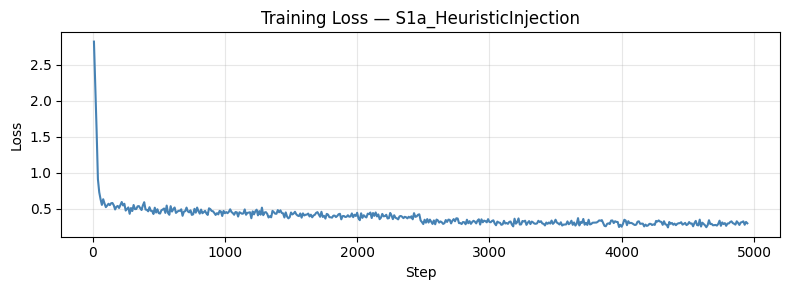

In [ ]:
print(f'Training {STRATEGY}...')
import glob as _glob
_ckpts = sorted(_glob.glob(str(CKPT_DIR / 'checkpoint-*')),
                key=lambda x: int(x.split('checkpoint-')[-1]))
_resume = _ckpts[-1] if _ckpts else False
if _resume: print(f'Resuming from checkpoint: {_resume}')
train_result = trainer.train(resume_from_checkpoint=_resume)
print(f'Loss: {train_result.training_loss:.4f}  Runtime: {train_result.metrics.get("train_runtime",0)/60:.1f} min')
adapter_dir = CKPT_DIR / 'final_adapter'
model.save_pretrained(adapter_dir); processor.save_pretrained(adapter_dir)
print(f'Saved -> {adapter_dir}')

logs = [e for e in trainer.state.log_history if 'loss' in e]
if logs:
    plt.figure(figsize=(8,3))
    plt.plot([e['step'] for e in logs], [e['loss'] for e in logs], color='steelblue')
    plt.title(f'Training Loss — {STRATEGY}'); plt.xlabel('Step'); plt.ylabel('Loss')
    plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'training_loss.png', dpi=150); plt.show()

In [ ]:
FastVisionModel.for_inference(model)
device = next(model.parameters()).device

def run_inference(conv):
    msgs = conv['messages']
    text_input = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(msgs)
    inputs = processor(text=[text_input], images=image_inputs, videos=video_inputs,
                       padding=True, return_tensors='pt').to(device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS,
                             do_sample=False, pad_token_id=processor.tokenizer.pad_token_id)
    return processor.batch_decode(out[:, inputs['input_ids'].shape[1]:], skip_special_tokens=True)[0].strip()

LABEL_NORM = {'mischaracterisation':'mischaracterization','ocr_problem':'OCR',
              'ocr problem':'OCR','ocr':'OCR','fabrication':'invention'}

def parse_model_output(raw):
    m = re.search(r'\[.*\]', raw, re.DOTALL)
    if not m: return []
    try: spans = json.loads(m.group())
    except: return []
    out = []
    for sp in spans:
        if not isinstance(sp, dict) or 'text' not in sp: continue
        text  = str(sp['text']).strip()
        if not text: continue
        label = LABEL_NORM.get(str(sp.get('label','other')).lower().strip(),
                               str(sp.get('label','other')).lower().strip())
        if label not in VALID_LABELS: label = 'other'
        prob = max(0.0, min(1.0, float(sp.get('prob', 0.8))))
        out.append({'text': text, 'prob': prob, 'label': label})
    return out

def find_span_pos(response, text):
    if not text: return None
    pos = response.find(text)
    if pos != -1: return pos, pos + len(text)
    pos = response.lower().find(text.lower())
    if pos != -1: return pos, pos + len(text)
    stripped = re.sub(r'[\*\_`]+', '', text).strip()
    if stripped and stripped != text:
        pos = response.lower().find(stripped.lower())
        if pos != -1: return pos, pos + len(stripped)
    if len(text) >= 8:
        tl, rl, tlen = text.lower(), response.lower(), len(text)
        step = max(1, tlen // 4)
        best_r, best_pos = 0.0, 0
        for i in range(0, max(1, len(response)-tlen+1), step):
            r = difflib.SequenceMatcher(None, rl[i:i+tlen], tl).ratio()
            if r > best_r: best_r, best_pos = r, i
        for i in range(max(0, best_pos-step), min(len(response)-tlen+1, best_pos+step+1)):
            r = difflib.SequenceMatcher(None, rl[i:i+tlen], tl).ratio()
            if r > best_r: best_r, best_pos = r, i
        if best_r >= 0.80: return best_pos, best_pos + tlen
    return None

def map_spans_to_positions(response, parsed):
    result, used = [], set()
    for sp in parsed:
        pos = find_span_pos(response, sp['text'])
        if pos is None: continue
        start, end = pos
        if len(set(range(start, end)) & used) > (end-start)*0.5: continue
        result.append({'start': start, 'end': end, 'prob': sp['prob'], 'label': sp['label']})
        used.update(range(start, end))
    return sorted(result, key=lambda x: x['start'])

def predict_one(conv):
    return map_spans_to_positions(conv['_response'], parse_model_output(run_inference(conv)))

def span_iou(pred, gold):
    p = set(i for s in pred for i in range(s['start'], s['end']))
    g = set(i for s in gold for i in range(s['start'], s['end']))
    if not p and not g: return 1.0
    return len(p & g) / len(p | g)

def spearman_rho(pred, gold, resp_len):
    pa = np.zeros(resp_len); ga = np.zeros(resp_len)
    for s in pred:
        for i in range(s['start'], min(s['end'], resp_len)): pa[i] = max(pa[i], s['prob'])
    for s in gold:
        for i in range(s['start'], min(s['end'], resp_len)): ga[i] = max(ga[i], s['prob'])
    if np.allclose(pa, pa[0]) and np.allclose(ga, ga[0]):
        return 1.0 if np.allclose(pa, ga) else 0.0
    rho, _ = spearmanr(pa, ga)
    return float(rho) if not np.isnan(rho) else 0.0

def category_f1(pred, gold, min_iou=0.3):
    tp, fp, fn = Counter(), Counter(), Counter()
    used_gold, used_pred = set(), set()
    for pi, p in enumerate(pred):
        pc = set(range(p['start'], p['end']))
        best_iou, best_gi = 0.0, -1
        for gi, g in enumerate(gold):
            if gi in used_gold: continue
            gc = set(range(g['start'], g['end']))
            iou = len(pc & gc) / max(len(pc | gc), 1)
            if iou > best_iou: best_iou, best_gi = iou, gi
        if best_iou >= min_iou and best_gi != -1:
            if p['label'] == gold[best_gi]['label']: tp[gold[best_gi]['label']] += 1
            else: fp[p['label']] += 1; fn[gold[best_gi]['label']] += 1
            used_gold.add(best_gi); used_pred.add(pi)
    for pi, p in enumerate(pred):
        if pi not in used_pred: fp[p['label']] += 1
    for gi, g in enumerate(gold):
        if gi not in used_gold: fn[g['label']] += 1
    scores = {}
    for cat in LABEL_ORDER:
        prec = tp[cat] / max(tp[cat]+fp[cat], 1)
        rec  = tp[cat] / max(tp[cat]+fn[cat], 1)
        scores[cat] = 2*prec*rec / max(prec+rec, 1e-9)
    scores['macro'] = float(np.mean(list(scores.values())))
    return scores

def evaluate_predictions(convs, predictions):
    ious, rhos, all_pred, all_gold = [], [], [], []
    for conv in convs:
        gold = conv['_labels']; pred = predictions.get(conv['_id'], [])
        ious.append(span_iou(pred, gold))
        rhos.append(spearman_rho(pred, gold, len(conv['_response'])))
        all_pred.extend(pred); all_gold.extend(gold)
    return {'mean_iou': float(np.mean(ious)), 'mean_spearman': float(np.nanmean(rhos)),
            'cat_f1': category_f1(all_pred, all_gold), 'n': len(convs)}

print('Inference + metric functions ready.')

Inference + metric functions ready.


In [ ]:
val_by_lang = defaultdict(list)
for conv in all_val_convs: val_by_lang[conv['_lang']].append(conv)

val_predictions = {}
for lang, convs in val_by_lang.items():
    convs = convs[:MAX_VAL_SAMPLES]
    print(f'Evaluating {lang.upper()} ({len(convs)} samples)...')
    for conv in tqdm(convs, desc=lang.upper()):
        try: val_predictions[conv['_id']] = predict_one(conv)
        except Exception as e: val_predictions[conv['_id']] = []

Evaluating EN (200 samples)...


EN:   0%|          | 0/200 [00:00<?, ?it/s]

Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

Evaluating FR (200 samples)...


FR:   0%|          | 0/200 [00:00<?, ?it/s]

...

IT:   0%|          | 0/200 [00:00<?, ?it/s]

Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

Evaluating ZH (200 samples)...


ZH:   0%|          | 0/200 [00:00<?, ?it/s]

Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

VALIDATION RESULTS — S1a_HeuristicInjection
[EN]  IoU=0.2117  Spearman=0.2651  CatF1=0.2227
  OCR F1=0.0652    miscounting F1=0.3962    mischaracterization F1=0.3131    invention F1=0.2315    other F1=0.1071  
[FR]  IoU=0.2731  Spearman=0.2991  CatF1=0.2308
  OCR F1=0.0714    miscounting F1=0.4286    mischaracterization F1=0.3208    invention F1=0.3333    other F1=0.0000  
[IT]  IoU=0.2718  Spearman=0.3277  CatF1=0.2789
  OCR F1=0.1111    miscounting F1=0.3636    mischaracterization F1=0.3651    invention F1=0.4169    other F1=0.1379  
[ZH]  IoU=0.2944  Spearman=0.3153  CatF1=0.2113
  OCR F1=0.0606    miscounting F1=0.3235    mischaracterization F1=0.1807    invention F1=0.3763    other F1=0.1154  
[OVERALL]  IoU=0.2627  Spearman=0.3018  CatF1=0.2300
Saved -> /content/drive/MyDrive/shroom-visions/ft_predictions_S1a_HeuristicInjection/S1a_HeuristicInjection_results.csv

COMPARISON: Baseline vs S1a_HeuristicInjection
Language Span IoU (base) Span IoU (S1a_Heuristi) Span IoU Δ Spearman rh

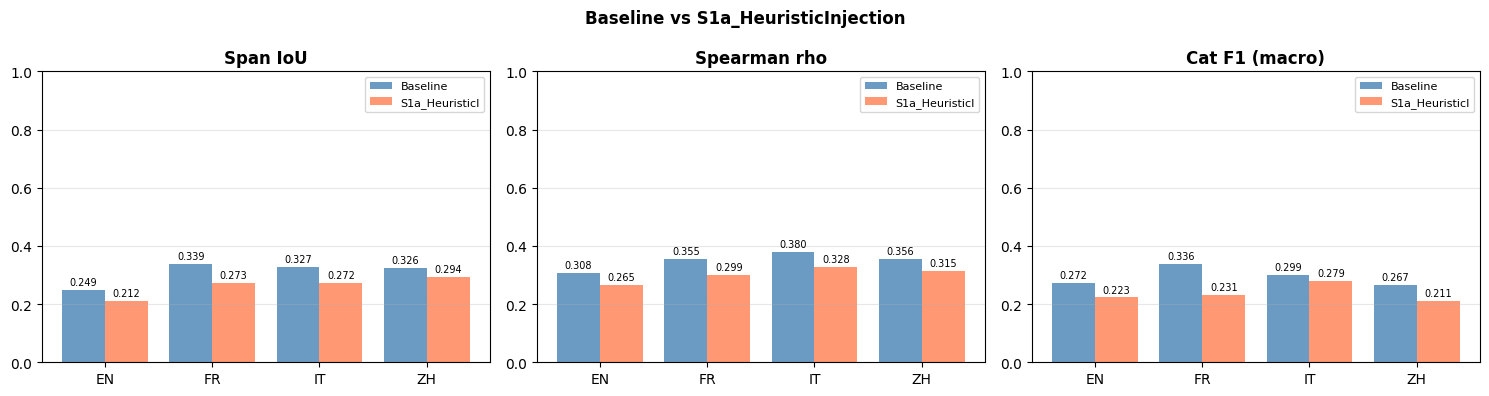

In [ ]:
results_by_lang = {}
print('=' * 60)
print(f'VALIDATION RESULTS — {STRATEGY}')
print('=' * 60)
for lang, convs in val_by_lang.items():
    m = evaluate_predictions(convs[:MAX_VAL_SAMPLES], val_predictions)
    results_by_lang[lang] = m
    print(f'[{lang.upper()}]  IoU={m["mean_iou"]:.4f}  Spearman={m["mean_spearman"]:.4f}  CatF1={m["cat_f1"]["macro"]:.4f}')
    for cat in TARGET_CATEGORIES:
        print(f'  {cat} F1={m["cat_f1"].get(cat,0):.4f}', end='  ')
    print()

all_val_limited = [c for lc in val_by_lang.values() for c in lc[:MAX_VAL_SAMPLES]]
overall = evaluate_predictions(all_val_limited, val_predictions)
print(f'[OVERALL]  IoU={overall["mean_iou"]:.4f}  Spearman={overall["mean_spearman"]:.4f}  CatF1={overall["cat_f1"]["macro"]:.4f}')

rows = []
for lang in LANGUAGES:
    if lang not in results_by_lang: continue
    m = results_by_lang[lang]
    row = {'Language': lang.upper(), 'Span IoU': round(m['mean_iou'],4),
           'Spearman rho': round(m['mean_spearman'],4), 'Cat F1 (macro)': round(m['cat_f1']['macro'],4)}
    for cat in LABEL_ORDER: row[f'F1({cat[:4]})'] = round(m['cat_f1'].get(cat,0.0),4)
    rows.append(row)
row_all = {'Language':'OVERALL','Span IoU':round(overall['mean_iou'],4),
           'Spearman rho':round(overall['mean_spearman'],4),'Cat F1 (macro)':round(overall['cat_f1']['macro'],4)}
for cat in LABEL_ORDER: row_all[f'F1({cat[:4]})'] = round(overall['cat_f1'].get(cat,0.0),4)
rows.append(row_all)
results_df = pd.DataFrame(rows)
results_df.to_csv(OUTPUT_DIR / f'{STRATEGY}_results.csv', index=False)
print(f'Saved -> {OUTPUT_DIR}/{STRATEGY}_results.csv')

if BASELINE_CSV.exists():
    baseline_df = pd.read_csv(BASELINE_CSV)
    if 'Spearman \u03c1' in baseline_df.columns:
        baseline_df = baseline_df.rename(columns={'Spearman \u03c1': 'Spearman rho'})
    metrics = ['Span IoU', 'Spearman rho', 'Cat F1 (macro)']
    comparison_rows = []
    for _, brow in baseline_df.iterrows():
        lang = brow['Language']
        arow = results_df[results_df['Language'] == lang]
        if arow.empty: continue
        arow = arow.iloc[0]
        row = {'Language': lang}
        for m in metrics:
            bval = float(brow[m]) if m in brow else 0.0
            aval = float(arow[m]) if m in arow.index else 0.0
            delta = aval - bval
            sign = '+' if delta >= 0 else ''
            row[f'{m} (base)'] = f'{bval:.4f}'
            row[f'{m} ({STRATEGY[:12]})'] = f'{aval:.4f}'
            row[f'{m} \u0394'] = f'{sign}{delta:.4f}'
        comparison_rows.append(row)
    cmp_df = pd.DataFrame(comparison_rows)
    print('\n' + '='*70)
    print(f'COMPARISON: Baseline vs {STRATEGY}')
    print('='*70)
    print(cmp_df.to_string(index=False))

    langs_p = [r['Language'] for r in comparison_rows if r['Language'] != 'OVERALL']
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, met in zip(axes, metrics):
        bv = [float(baseline_df[baseline_df['Language']==l][met].values[0]) for l in langs_p]
        av = [float(results_df[results_df['Language']==l][met].values[0]) for l in langs_p]
        x = np.arange(len(langs_p))
        ax.bar(x-0.2, bv, 0.4, label='Baseline', color='steelblue', alpha=0.8)
        ax.bar(x+0.2, av, 0.4, label=STRATEGY[:14], color='coral', alpha=0.8)
        for xi,(b,a) in enumerate(zip(bv,av)):
            ax.text(xi-0.2, b+0.01, f'{b:.3f}', ha='center', va='bottom', fontsize=7)
            ax.text(xi+0.2, a+0.01, f'{a:.3f}', ha='center', va='bottom', fontsize=7)
        ax.set_xticks(x); ax.set_xticklabels(langs_p)
        ax.set_title(met, fontweight='bold'); ax.set_ylim(0, 1)
        ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
    plt.suptitle(f'Baseline vs {STRATEGY}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'comparison_chart.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f'Baseline CSV not found at {BASELINE_CSV}. Run Finetune_Multimodal_RealData.ipynb first.')